In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [40]:
df = pd.read_csv('iris.csv')

In [41]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [42]:
df = df.iloc[:,1:]

In [43]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [44]:
from sklearn.preprocessing import LabelEncoder

In [45]:
encoder = LabelEncoder()

In [46]:
df['Species'] = encoder.fit_transform(df['Species'])

In [47]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [48]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [49]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

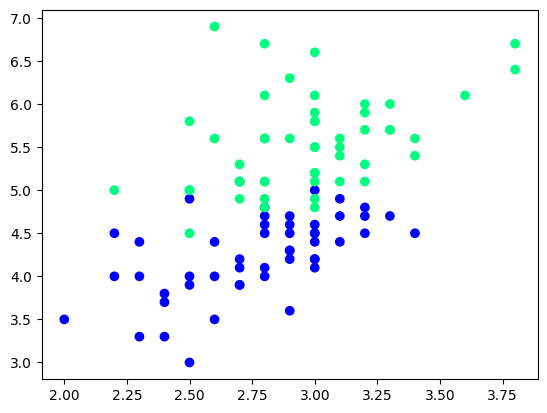

In [51]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [52]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
92,2.6,4.0,1
69,2.5,3.9,1
65,3.1,4.4,1
80,2.4,3.8,1
101,2.7,5.1,2
84,3.0,4.5,1
97,2.9,4.3,1
102,3.0,5.9,2
93,2.3,3.3,1
85,3.4,4.5,1


In [53]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [54]:
df_train

,SepalWidthCm,PetalLengthCm,Species
96,2.9,4.2,1
85,3.4,4.5,1
51,3.2,4.5,1
62,2.2,4.0,1
95,3.0,4.2,1
122,2.8,6.7,2
66,3.0,4.5,1
144,3.3,5.7,2
73,2.8,4.7,1
107,2.9,6.3,2


In [55]:
df_val

,SepalWidthCm,PetalLengthCm,Species
94,2.7,4.2,1
100,3.3,6.0,2
114,2.8,5.1,2
134,2.6,5.6,2
135,3.0,6.1,2


In [ ]:
df_test


,SepalWidthCm,PetalLengthCm,Species
98,2.5,3.0,1
109,3.6,6.1,2
119,2.2,5.0,2
88,3.0,4.1,1
72,2.5,4.9,1


In [57]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [58]:
y_test

array([1, 2, 2, 2, 2])

# Case 1 - Bagging

In [59]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
95,3.0,4.2,1
62,2.2,4.0,1
66,3.0,4.5,1
62,2.2,4.0,1
122,2.8,6.7,2
85,3.4,4.5,1
66,3.0,4.5,1
122,2.8,6.7,2


In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [61]:
dt_bag1 = DecisionTreeClassifier()

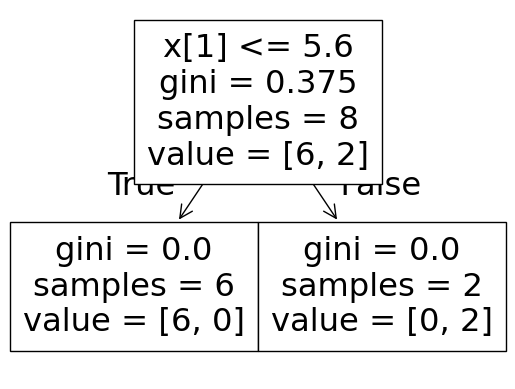

0.6


c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


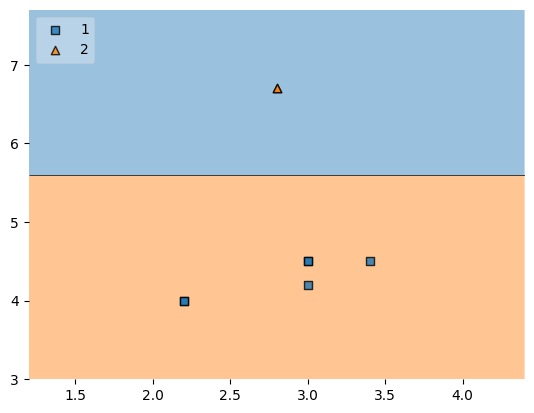

In [62]:
evaluate(dt_bag1,X,y)

In [63]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
51,3.2,4.5,1
95,3.0,4.2,1
122,2.8,6.7,2
51,3.2,4.5,1
95,3.0,4.2,1
73,2.8,4.7,1
62,2.2,4.0,1
122,2.8,6.7,2


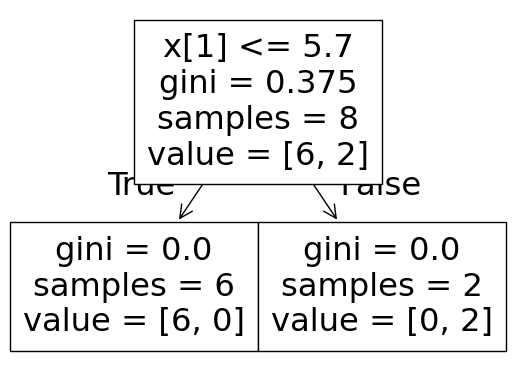

0.6


c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


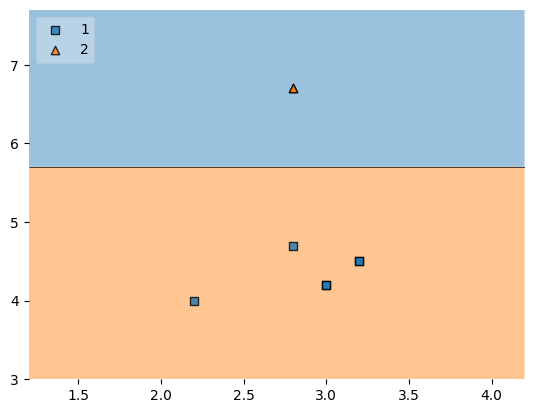

In [64]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [65]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
51,3.2,4.5,1
107,2.9,6.3,2
96,2.9,4.2,1
144,3.3,5.7,2
122,2.8,6.7,2
96,2.9,4.2,1
96,2.9,4.2,1
122,2.8,6.7,2


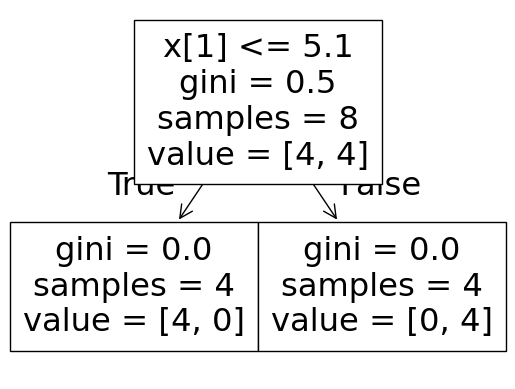

0.8


c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


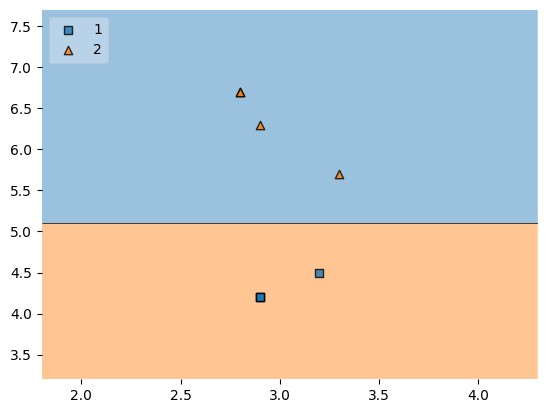

In [66]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [67]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [68]:
df_test

,SepalWidthCm,PetalLengthCm,Species
98,2.5,3.0,1
109,3.6,6.1,2
119,2.2,5.0,2
88,3.0,4.1,1
72,2.5,4.9,1


In [69]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [70]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
96,2.9,4.2,1
85,3.4,4.5,1
51,3.2,4.5,1
62,2.2,4.0,1
95,3.0,4.2,1
122,2.8,6.7,2
66,3.0,4.5,1
144,3.3,5.7,2
73,2.8,4.7,1
107,2.9,6.3,2


In [71]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
107,2.9,6.3,2
85,3.4,4.5,1
66,3.0,4.5,1
51,3.2,4.5,1
73,2.8,4.7,1
62,2.2,4.0,1
122,2.8,6.7,2
96,2.9,4.2,1


# Random Subspaces

In [72]:
df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df1 = df1.sample(10)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/iris/Iris.csv'

In [ ]:
df1

NameError: name 'df1' is not defined

In [ ]:
df1.sample(2,replace=True,axis=1)

NameError: name 'df1' is not defined

# Random Patches

In [ ]:
df1

NameError: name 'df1' is not defined

In [ ]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalLengthCm,Id
38,4.4,39
10,5.4,11
109,7.2,110
62,6.0,63
134,6.1,135
12,4.8,13
10,5.4,11
134,6.1,135
